In [169]:
!git clone https://github.com/EgorHI/mnist-influence-project.git
%cd /content/mnist-influence-project
!pip install -r requirements.txt


fatal: destination path 'mnist-influence-project' already exists and is not an empty directory.
/content/mnist-influence-project


Загрузка MNIST и правильное разбиение

In [170]:
# =========================
# 1. Imports and seed
# =========================
import random
import numpy as np
import torch

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset #исользование батчей и взятие части датасета по индексам
from sklearn.model_selection import train_test_split #для разбиаения данных на train, validation, test

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed) #случайность на gpu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выбор устройства: gpu (сuda) или cpu
print("Device:", device)
print("Seed:", seed)

Device: cuda
Seed: 42


In [171]:
# =========================
# 2. Load MNIST
# =========================
transform = transforms.ToTensor() # приводим к тензору

#train часть датасета
mnist_train_full = datasets.MNIST( #объект датасета MNIST
    root="./data", #папка для сохранения
    train=True, #Берем ли обцучающую часть или нет
    download=True, #если датасета нет, его надо загрузить
    transform=transform #к каждому элементу применяй то что в transform
)

#test часть датасета
mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Full train size:", len(mnist_train_full))  # 60000
print("Test size:", len(mnist_test))              # 10000

Full train size: 60000
Test size: 10000


In [172]:
# =========================
# 3. Stratified split of TRAIN into 60% / 30% / 10%
# =========================
targets = mnist_train_full.targets.numpy() #ответы target в виде массива
all_indices = np.arange(len(mnist_train_full)) #массив из чисел от 0 до размер части train - 1 для индексации

# Сначала делим на 60% и 40%
idx_60, idx_40 = train_test_split( #делит набор случайно на 2 части
    all_indices, #что делим
    test_size=0.40,
    stratify=targets, #раздели так чтобы распределение внутри targets сохранялось
    random_state=seed #фиксируем случайность
)

# Потом 40% делим на 30% и 10%
# 30% : 10% = 3 : 1, значит внутри этих 40%
# нужно выделить 25% под финальные 10% и 75% под финальные 30%
targets_40 = targets[idx_40]

idx_30, idx_10 = train_test_split(
    idx_40,
    test_size=0.25,
    stratify=targets_40,
    random_state=seed
)

print("Split sizes:")
print("60% split:", len(idx_60))
print("30% split:", len(idx_30))
print("10% split:", len(idx_10))
print("Check total:", len(idx_60) + len(idx_30) + len(idx_10))

Split sizes:
60% split: 36000
30% split: 18000
10% split: 6000
Check total: 60000


In [173]:
# =========================
# 4. Create subsets
# =========================
mnist_train_60 = Subset(mnist_train_full, idx_60) #взять часть датасета по списку индексов
mnist_train_30 = Subset(mnist_train_full, idx_30)   # ЭТУ часть потом используем для обучения baseline
mnist_train_10 = Subset(mnist_train_full, idx_10)   # ЭТУ часть потом используем в influence block

print("Subset sizes:")
print("mnist_train_60:", len(mnist_train_60))
print("mnist_train_30:", len(mnist_train_30))
print("mnist_train_10:", len(mnist_train_10))
print("mnist_test:", len(mnist_test))

Subset sizes:
mnist_train_60: 36000
mnist_train_30: 18000
mnist_train_10: 6000
mnist_test: 10000


In [174]:
# =========================
# 5. Dataloaders
# =========================
batch_size = 128

train30_loader = DataLoader(mnist_train_30, batch_size=batch_size, shuffle=True) #загрузчик. берет датасет, делит его на батчи, перемешивает и отдает
train10_loader = DataLoader(mnist_train_10, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

print("Number of batches:")
print("train30_loader:", len(train30_loader))
print("train10_loader:", len(train10_loader))
print("test_loader:", len(test_loader))

Number of batches:
train30_loader: 141
train10_loader: 47
test_loader: 79


In [175]:
# =========================
# 6. Check class balance
# =========================
#получаем метки (ответы) из full_dataset по инедексам нужного поднабора
def get_labels_from_subset(full_dataset, subset_indices):
    return full_dataset.targets[subset_indices].numpy()

#печатаем распределение классов
def print_class_distribution(name, labels):
    unique, counts = np.unique(labels, return_counts=True) #находим уникальные значения в массиве и их количество
    total = len(labels)
    print(f"\n{name}")
    for cls, cnt in zip(unique, counts):
        print(f"class {cls}: {cnt} ({cnt / total:.4f})")

labels_60 = get_labels_from_subset(mnist_train_full, idx_60)
labels_30 = get_labels_from_subset(mnist_train_full, idx_30)
labels_10 = get_labels_from_subset(mnist_train_full, idx_10)
labels_test = mnist_test.targets.numpy()

print_class_distribution("60% split", labels_60)
print_class_distribution("30% split", labels_30)
print_class_distribution("10% split", labels_10)
print_class_distribution("test split", labels_test)


60% split
class 0: 3554 (0.0987)
class 1: 4045 (0.1124)
class 2: 3575 (0.0993)
class 3: 3678 (0.1022)
class 4: 3505 (0.0974)
class 5: 3253 (0.0904)
class 6: 3551 (0.0986)
class 7: 3759 (0.1044)
class 8: 3511 (0.0975)
class 9: 3569 (0.0991)

30% split
class 0: 1777 (0.0987)
class 1: 2023 (0.1124)
class 2: 1787 (0.0993)
class 3: 1840 (0.1022)
class 4: 1753 (0.0974)
class 5: 1626 (0.0903)
class 6: 1775 (0.0986)
class 7: 1879 (0.1044)
class 8: 1755 (0.0975)
class 9: 1785 (0.0992)

10% split
class 0: 592 (0.0987)
class 1: 674 (0.1123)
class 2: 596 (0.0993)
class 3: 613 (0.1022)
class 4: 584 (0.0973)
class 5: 542 (0.0903)
class 6: 592 (0.0987)
class 7: 627 (0.1045)
class 8: 585 (0.0975)
class 9: 595 (0.0992)

test split
class 0: 980 (0.0980)
class 1: 1135 (0.1135)
class 2: 1032 (0.1032)
class 3: 1010 (0.1010)
class 4: 982 (0.0982)
class 5: 892 (0.0892)
class 6: 958 (0.0958)
class 7: 1028 (0.1028)
class 8: 974 (0.0974)
class 9: 1009 (0.1009)


In [176]:
# =========================
# 7. Quick sanity check: one batch
# =========================
images, labels = next(iter(train30_loader)) #создали итератор по train30_loadar, и берем из него первыый батч

print("Batch images shape:", images.shape)  # показывает форму тензора картинок и его размерности
print("Batch labels shape:", labels.shape)  # форма тензора меток
print("Min pixel:", images.min().item()) #берет наименьшее значение и превращает его в число - min пискель
print("Max pixel:", images.max().item()) #max пиксель

Batch images shape: torch.Size([128, 1, 28, 28])
Batch labels shape: torch.Size([128])
Min pixel: 0.0
Max pixel: 1.0


Подготовка ResNet-18 под MNIST

In [177]:
# =========================
# 8. Prepare ResNet-18 for MNIST
# =========================
import torch
import torch.nn as nn #ут слои нейронки
from torchvision.models import resnet18, ResNet18_Weights #архитектура resnet18 и набор готовых весов

# 1) Загружаем ResNet-18 с предобученными ImageNet-весами
model = resnet18(weights=ResNet18_Weights.DEFAULT) #загрузка модели с стандартными весами

# 2) Замораживаем ВСЕ параметры
for param in model.parameters():
    param.requires_grad = False #градиент для этого параметра обновлять не надо

# 3) Заменяем первый слой:
#    было: Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
#    стало: Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
#    Этот новый слой будет ОБУЧАТЬСЯ
model.conv1 = nn.Conv2d( #первый слой который ищет признаки
    in_channels=1, #на вход 1 канал
    out_channels=64, # строит 64 карты признков
    kernel_size=7, #смотрит на окно 7x7 пикселей
    stride=2, #уменьшает пространсвтенный размер изображений
    padding=3, #добавляем рамки из 0
    bias=False #смещение (тут тулько масштабируем и комбинируем вход)
)

# 4) Заменяем последний слой под 10 классов MNIST
# берем признаки и преврящает их в оценки принадлежности к классу
num_features = model.fc.in_features #сколько признаков на последнем слое
model.fc = nn.Linear(num_features, 10) #теперь 10 признаков

# 5) Разрешаем обучение только новым слоям
for param in model.conv1.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# 6) Переносим модель на device
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [178]:
# =========================
# 9. Sanity check: one forward pass
# =========================
images, labels = next(iter(train30_loader))
images = images.to(device)

with torch.no_grad(): #внутри блока не нужно считать градиенты
    outputs = model(images)#прогон картинок через модель

print("Input shape :", images.shape)   # ожидаем [batch_size, 1, 28, 28]
print("Output shape:", outputs.shape)  # ожидаем [batch_size, 10]

Input shape : torch.Size([128, 1, 28, 28])
Output shape: torch.Size([128, 10])


In [179]:
# =========================
# 10. Check trainable parameters
# =========================
trainable_params = [] #обучаемые праметры
frozen_params = []#замороженные параметры
#цикл по параметрам модели
for name, param in model.named_parameters():
    if param.requires_grad: #если параметр обучаемый
        trainable_params.append(name)
    else:
        frozen_params.append(name)

print("Trainable parameters:")
for name in trainable_params:
    print("  ", name)

print("\nNumber of trainable tensors:", len(trainable_params))
print("Number of frozen tensors   :", len(frozen_params))

Trainable parameters:
   conv1.weight
   fc.weight
   fc.bias

Number of trainable tensors: 3
Number of frozen tensors   : 59


Обучение базовой модели на нормальных данных

In [180]:
# =========================
# 11. Training setup
# =========================
import os #для работы с файлами и папками
import json #для сохранения логов и меток
from datetime import datetime #для сохранения текущего времени

import torch
import torch.nn as nn #готовые слои, функции, модели
import torch.optim as optim #оптимизаторы, которые обновляют веса модели
# Папки для артефактов
os.makedirs("models", exist_ok=True) #создание папки с моделями
os.makedirs("logs", exist_ok=True) #метрики, логи, результаты

# Функция потерь
criterion = nn.CrossEntropyLoss()

# Оптимизатор: обновляем только обучаемые параметры
optimizer = optim.Adam( #меняем веса для уменьшения loss, Adam - популярный оптимизатор
    filter(lambda p: p.requires_grad, model.parameters()), #оставляет только обучаемые парампетры
    lr=1e-3 #скорость обучения
)

# Гиперпараметры
num_epochs = 5

print("Training setup is ready.")

Training setup is ready.


In [181]:
# =========================
# 12. Helper functions
# =========================
#batchnorm - слой который хранит внутреннюю статистику
def set_batchnorm_eval(m):
    """
    Если слой - BatchNorm, переводим его в eval(),
    чтобы не обновлять внутреннюю статистику.
    Это полезно, когда backbone фактически заморожен.
    """
    if isinstance(m, nn.BatchNorm2d): #nn.BatchNorm2d - это слой нейронк подправляющий значения для стабильности и скорости
        m.eval() #перевели слой в режим проверки

#Обучает модель одну эпоху
def train_one_epoch(model, loader, criterion, optimizer, device): #модельб dataloadaer, функция потерь, оптимизатор, cpu или cuda
    model.train() #в режим обучения

    # Замораживаем поведение BatchNorm-слоев (обучаем первый и последний слои)
    model.apply(set_batchnorm_eval) #проходит по всем модулям модели и замораживает

    running_loss = 0.0 #суммарный loss
    correct = 0 #количество верно классифицированных примпров
    total = 0 #всего примеров

    #цикл по батчам
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() #обнуляем старые градиенты

        outputs = model(images) #получили предсказание
        loss = criterion(outputs, labels) #применяем функцию Loss

        loss.backward() #вычисляем градиенты для обучаемых параметров
        optimizer.step() #Обновляем веса

        running_loss += loss.item() * images.size(0) #loss*размер батча

        preds = outputs.argmax(dim=1) #берем индекс максимального значения по объекту
        correct += (preds == labels).sum().item() #считаем число верных ответов
        total += labels.size(0) #прибавляем размер текущего батча

    epoch_loss = running_loss / total #редняя ошибка на объект по всей эпохе
    epoch_acc = correct / total #доля верных ответов
    return epoch_loss, epoch_acc


@torch.no_grad() #внутри функции не надо хранить граф и считать градиенты
#оценка модели
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    loss_value = running_loss / total
    acc_value = correct / total
    return loss_value, acc_value

#сохраняем метрики
def save_metrics_to_json(filepath, metrics_dict):
    with open(filepath, "w", encoding="utf-8") as f: #путь до файла, режим записи, кодировка
        json.dump(metrics_dict, f, ensure_ascii=False, indent=2) #чтобы хорошо соханять словарь, с русскими буквами и отступами

In [182]:
# =========================
# 13. Train baseline model on normal data
# =========================
best_test_acc = 0.0 #лучшая точность на тесте
best_model_path = "models/resnet18_mnist_baseline.pt" #путь куда сохранять лучшую модель
#словарь для хранения истории обучения
history = {
    "train_loss": [], #ошибка на обучении
    "train_acc": [],#точность на обучении
    "test_loss": [],#ошибка на тесте
    "test_acc": []#точность на тесте
}
#цикл по эпохам
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch( #функция выше
        model=model,
        loader=train30_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    test_loss, test_acc = evaluate( #фукция выше
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f}"
    )

    # Сохраняем лучшую модель по test accuracy
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), best_model_path) #сохраняем параметры модели

print("\nTraining finished.")
print("Best test accuracy:", round(best_test_acc, 4))
print("Best model saved to:", best_model_path)

Epoch 1/5 | train_loss=1.2945 | train_acc=0.6308 | test_loss=0.5778 | test_acc=0.8474
Epoch 2/5 | train_loss=0.4660 | train_acc=0.8674 | test_loss=0.3460 | test_acc=0.9027
Epoch 3/5 | train_loss=0.3280 | train_acc=0.9043 | test_loss=0.2773 | test_acc=0.9202
Epoch 4/5 | train_loss=0.2648 | train_acc=0.9202 | test_loss=0.2434 | test_acc=0.9273
Epoch 5/5 | train_loss=0.2323 | train_acc=0.9302 | test_loss=0.2229 | test_acc=0.9331

Training finished.
Best test accuracy: 0.9331
Best model saved to: models/resnet18_mnist_baseline.pt


In [183]:
# =========================
# 14. Load best model and final evaluation
# =========================
model.load_state_dict(torch.load(best_model_path, map_location=device)) #загружаем лучшую сохраненную модель

#снова тесритуем
final_test_loss, final_test_acc = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device
)

print("Final baseline test loss:", round(final_test_loss, 4))
print("Final baseline test accuracy:", round(final_test_acc, 4))

Final baseline test loss: 0.2229
Final baseline test accuracy: 0.9331


In [184]:
# =========================
# 15. Save baseline metrics to JSON
# =========================
#сохраняем в словарь итоговую инфу
baseline_metrics = {
    "experiment_name": "baseline_normal_data",
    "timestamp": datetime.now().isoformat(),
    "random_seed": seed,
    "train_subset_name": "mnist_train_30",
    "train_subset_size": len(mnist_train_30),
    "test_subset_name": "mnist_test",
    "test_subset_size": len(mnist_test),
    "num_epochs": num_epochs,
    "learning_rate": 1e-3,
    "final_test_loss": float(final_test_loss),
    "final_test_accuracy": float(final_test_acc),
    "best_test_accuracy_during_training": float(best_test_acc),
    "model_path": best_model_path
}

baseline_metrics_path = "logs/baseline_metrics.json"
save_metrics_to_json(baseline_metrics_path, baseline_metrics) #сохраняем словарь в json

print("Baseline metrics saved to:", baseline_metrics_path)
print(json.dumps(baseline_metrics, ensure_ascii=False, indent=2)) #печатает словарь в консоль (преобразовав в строку)

Baseline metrics saved to: logs/baseline_metrics.json
{
  "experiment_name": "baseline_normal_data",
  "timestamp": "2026-03-19T23:32:42.596327",
  "random_seed": 42,
  "train_subset_name": "mnist_train_30",
  "train_subset_size": 18000,
  "test_subset_name": "mnist_test",
  "test_subset_size": 10000,
  "num_epochs": 5,
  "learning_rate": 0.001,
  "final_test_loss": 0.222903315359354,
  "final_test_accuracy": 0.9331,
  "best_test_accuracy_during_training": 0.9331,
  "model_path": "models/resnet18_mnist_baseline.pt"
}


Реализация influence score

In [185]:
# =========================
# 16. Influence setup
# =========================
import numpy as np
from tqdm.auto import tqdm #показать полоску с числами
from torch.utils.data import DataLoader

# На influence этапе лучше работать с уже лучшей baseline-моделью
model.load_state_dict(torch.load(best_model_path, map_location=device)) #читаем сохраненные веса и загружаем в модель
model.eval() #в режим проверки

# Loader для proxy-части (это 10% split из train)
#dataloadar для 10 % из Train
proxy10_loader = DataLoader(
    mnist_train_10,
    batch_size=128,
    shuffle=False
)

# Loader для LiSSA / HVP по train30
#для расчета influence
influence_train_loader = DataLoader(
    mnist_train_30,
    batch_size=128,
    shuffle=True
)

# Loader по одному объекту, чтобы считать influence score для каждого train-примера
#считаем Influence для каждог объекта отдельно
train30_single_loader = DataLoader(
    mnist_train_30,
    batch_size=1,
    shuffle=False
)

print("Influence loaders are ready.")
print("proxy10 size:", len(mnist_train_10))
print("train30 size:", len(mnist_train_30))

Influence loaders are ready.
proxy10 size: 6000
train30 size: 18000


In [186]:
# =========================
# 17. Influence helper functions
# =========================
import torch
import torch.nn as nn

#берем только обучаемые параметры
def get_trainable_params(model):
    return [p for p in model.parameters() if p.requires_grad]

#склеивает тензоры в один длинный вектор
def flatten_tensors(tensors):
  #данные лежат непрерывным куском и тензор расплющивается
    return torch.cat([t.contiguous().view(-1) for t in tensors])

#как сильно и в какую сторону кривизна loss влияет на вектор
# H- матрица 2 производных
def hvp(loss, params, vec):
    """
    Hessian-vector product: H * vec
    где H — Hessian loss по trainable params
    """
    #считаем производые автоматически
    first_grads = torch.autograd.grad(
        loss, #от чего производная
        params, #переменные по которым производные
        create_graph=True, #так как потом будет барть производную еще раз
        retain_graph=True #не удалять граф после вычислений
    )
    flat_first_grads = flatten_tensors(first_grads) #градиенты расплющивают

    grad_dot_vec = torch.dot(flat_first_grads, vec)#Скалярное произведение с vec

    #и еще раз производную
    hv = torch.autograd.grad(
        grad_dot_vec,
        params,
        retain_graph=False
    )
    #отцепляют результат от графа и снова превращают в один длинный вектор
    hv = [h.detach() for h in hv]
    return flatten_tensors(hv)


@torch.no_grad()
#Считает, сколько в модели обучаемых чисел
def count_num_trainable_params(model):
    total = 0
    for p in model.parameters():
        if p.requires_grad:
            total += p.numel()
    return total

#в какую сторону proxy-набор хочет сдвинуть параметры модели?

def compute_dataset_gradient(model, loader, criterion, device, max_batches=None):
    """
    Считает средний градиент loss по всему loader.
    Это будет v = grad_theta L_proxy(theta).
    """
    model.eval() #без обучения
    params = get_trainable_params(model) #обучваемые параметры (выше)

    grad_accumulator = None
    total_items = 0
    # #Проход по всему proxy-loader
    for batch_idx, (images, labels) in enumerate(loader): #enumerate - знать номер
    #Ограничение по числу батчей
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        model.zero_grad(set_to_none=True) #тензор градиента удален
        outputs = model(images)
        loss = criterion(outputs, labels)

        #Получают градиент текущего батча.
        grads = torch.autograd.grad(loss, params, retain_graph=False, create_graph=False)
        #Переводят в один вектор
        flat_grads = flatten_tensors([g.detach() for g in grads])

        batch_size = images.size(0) #рзамер батча
        #средний градиент по всем объектам
        if grad_accumulator is None:
            grad_accumulator = flat_grads * batch_size
        else:
            grad_accumulator += flat_grads * batch_size

        #всего объектов
        total_items += batch_size

    #средний градиент
    avg_grad = grad_accumulator / total_items
    return avg_grad

#Эта функция выдаёт вектор, который нужен для influence score.
#LiSSA — это способ дёшево приблизить H^(-1)v, не строя и не обращая Hessian напрямую.
def lissa_inverse_hvp(
    model,
    train_loader,
    criterion,
    device,
    v,
    damping=0.01, #Немного “успокаивает” обновления, чтобы итерации были стабильнее.
    scale=25.0, #Масштабирование, чтобы шаги были адекватными.
    recursion_depth=200, #Сколько итераций делать.
    num_repeats=1 #Сколько раз повторить весь процесс и усреднить.
):
    """
    LiSSA-аппроксимация для H^{-1} v.
    """
    model.eval()
    params = get_trainable_params(model)

    ihvp = torch.zeros_like(v) #Тут будет копиться итог.

    for repeat in range(num_repeats):
        cur_estimate = v.clone() #Текущая оценка начинается с v.

        data_iter = iter(train_loader)
        #tqdm просто показывает прогресс-бар.
        for _ in tqdm(range(recursion_depth), desc=f"LiSSA repeat {repeat+1}/{num_repeats}"):
            try:
                images, labels = next(data_iter)
            except StopIteration:
                data_iter = iter(train_loader)
                images, labels = next(data_iter)

            images = images.to(device)
            labels = labels.to(device)

            model.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            #считают H * current_estimate.
            hv = hvp(loss, params, cur_estimate)
            #Обновляют оценку
            cur_estimate = v + (1.0 - damping) * cur_estimate - hv / scale

        ihvp += cur_estimate / scale #Добавляем результат в общий накопитель.

    ihvp /= num_repeats #В конце усредняют
    return ihvp

#Считает градиент loss для одного конкретного train-примера.
def compute_single_example_grad(model, image, label, criterion, device):
    """
    Градиент loss по одному train-примеру.
    """
    model.eval()
    params = get_trainable_params(model)

    image = image.to(device)
    label = label.to(device)

    model.zero_grad(set_to_none=True)
    outputs = model(image)
    loss = criterion(outputs, label)

    grads = torch.autograd.grad(loss, params, retain_graph=False, create_graph=False)
    flat_grads = flatten_tensors([g.detach() for g in grads])

    return flat_grads


print("Trainable parameter count:", count_num_trainable_params(model))

Trainable parameter count: 8266


In [187]:
# =========================
# 18. Compute proxy gradient on 10% split
# =========================
v_proxy = compute_dataset_gradient(
    model=model,
    loader=proxy10_loader,
    criterion=criterion,
    device=device,
    max_batches=None   # можно поставить число, если захочешь ускорить черновой прогон
)

print("Proxy gradient shape:", v_proxy.shape)
print("Proxy gradient norm :", torch.norm(v_proxy).item())

Proxy gradient shape: torch.Size([8266])
Proxy gradient norm : 0.40560194849967957


In [188]:
# =========================
# 19. Compute inverse-HVP approximation
# =========================
# Стартовые гиперпараметры.
# Если будет слишком медленно, сначала попробуй recursion_depth=100.
s_test = lissa_inverse_hvp(
    model=model,
    train_loader=influence_train_loader,
    criterion=criterion,
    device=device,
    v=v_proxy,
    damping=0.01,
    scale=25.0,
    recursion_depth=500,
    num_repeats=3
)

print("s_test shape:", s_test.shape)
print("s_test norm :", torch.norm(s_test).item())

LiSSA repeat 1/3:   0%|          | 0/500 [00:00<?, ?it/s]

LiSSA repeat 2/3:   0%|          | 0/500 [00:00<?, ?it/s]

LiSSA repeat 3/3:   0%|          | 0/500 [00:00<?, ?it/s]

s_test shape: torch.Size([8266])
s_test norm : 0.2655949294567108


In [189]:
# =========================
# 20. Compute influence scores for all samples in train30
# =========================
influence_scores = [] #сюда будем складывать score каждого train-объекта;

n_train30 = len(mnist_train_30) #размер основного train-набора.

for local_idx, (image, label) in enumerate(tqdm(train30_single_loader, desc="Influence scores")):
  #“как этот один объект толкает параметры модели”
    grad_z = compute_single_example_grad(
        model=model,
        image=image,
        label=label,
        criterion=criterion,
        device=device
    )
    #Оно показывает, насколько они направлены в одну сторону.
    score = -torch.dot(grad_z, s_test).item() / n_train30
    #Для каждого train-примера добавляем одно число.
    influence_scores.append(score)
#Переводим в numpy-массив
influence_scores = np.array(influence_scores, dtype=np.float64)

print("Done.")
print("Num scores:", len(influence_scores))
print("Min score :", influence_scores.min())
print("Max score :", influence_scores.max())
print("Mean      :", influence_scores.mean())

Influence scores:   0%|          | 0/18000 [00:00<?, ?it/s]

Done.
Num scores: 18000
Min score : -7.398109965854221e-05
Max score : 5.4933869176440766e-05
Mean      : -9.447733010074092e-07


Выбор top 5% и bottom 5% по influence

In [190]:
# =========================
# 21. Select top 5% most and least influential samples
# =========================
top_fraction = 0.05
k = max(1, int(len(influence_scores) * top_fraction)) #сколько объектов нужно выбрать

# Наиболее полезные для proxy/test предсказаний
most_influential_local = np.argsort(influence_scores)[:k]

# Наименее влиятельные
least_influential_local = np.argsort(np.abs(influence_scores))[:k]

# Индексы внутри исходного train MNIST (а не только внутри Subset)
#Переводит индексы из локальных в исходные индексы полного MNIST train.
most_influential_original = [int(idx_30[i]) for i in most_influential_local]
least_influential_original = [int(idx_30[i]) for i in least_influential_local]

print("k =", k)
print("Most influential local indices  (first 10):", most_influential_local[:10])
print("Least influential local indices (first 10):", least_influential_local[:10])

print("Most influential original indices  (first 10):", most_influential_original[:10])
print("Least influential original indices (first 10):", least_influential_original[:10])

k = 900
Most influential local indices  (first 10): [12207 11716  5283 11225  9467   134  4946  1517 10916  8381]
Least influential local indices (first 10): [17992  1858  4312  1088 12623  6586   498 17477 17075  3418]
Most influential original indices  (first 10): [34861, 16809, 33484, 53113, 8347, 41180, 10309, 52163, 17440, 25306]
Least influential original indices (first 10): [20056, 12872, 14309, 7067, 53615, 33418, 47773, 8331, 55746, 13769]


In [191]:
# =========================
# 22. Save influence results to JSON
# =========================
import os
import json
from datetime import datetime

os.makedirs("logs/influence", exist_ok=True)

influence_results = {
    "timestamp": datetime.now().isoformat(),
    "random_seed": seed,
    "source_subset_name": "mnist_train_30",
    "source_subset_size": len(mnist_train_30),
    "proxy_subset_name": "mnist_train_10",
    "proxy_subset_size": len(mnist_train_10),
    "selection_rule": "absolute_influence_score",
    "top_fraction": top_fraction,
    "num_selected": k,

    "most_influential_local_indices": [int(i) for i in most_influential_local],
    "least_influential_local_indices": [int(i) for i in least_influential_local],

    "most_influential_original_mnist_train_indices": most_influential_original,
    "least_influential_original_mnist_train_indices": least_influential_original,

    "most_influential_scores": [float(influence_scores[i]) for i in most_influential_local],
    "least_influential_scores": [float(influence_scores[i]) for i in least_influential_local]
}

influence_json_path = "logs/influence_top_bottom_5_percent.json"

with open(influence_json_path, "w", encoding="utf-8") as f:
    json.dump(influence_results, f, ensure_ascii=False, indent=2)

print("Influence indices saved to:", influence_json_path)

Influence indices saved to: logs/influence_top_bottom_5_percent.json


Блок атаки label flipping

In [192]:
# =========================
# 23. Label flipping attack helpers
# =========================
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

def sample_wrong_label(true_label, rng, num_classes=10):
    """
    Равномерно выбирает случайный класс, отличный от true_label.
    """
    new_label = rng.integers(0, num_classes - 1) # генератор случаных чисел
    if new_label >= true_label:
        new_label += 1
    return int(new_label)

class PoisonedSubset(Dataset):
    """
    Датасет поверх mnist_train_30:
    - берем только selected_local_indices
    - для части индексов подменяем label через poisoned_label_map
    """
  #(текущий экземпляр, исходный датасет, какие элементы пойдут, словарь какие меткиотравить)
    def __init__(self, base_subset, selected_local_indices, poisoned_label_map):
        self.base_subset = base_subset
        self.selected_local_indices = [int(i) for i in selected_local_indices]
        self.poisoned_label_map = {int(k): int(v) for k, v in poisoned_label_map.items()}

    def __len__(self):
        return len(self.selected_local_indices)

    def __getitem__(self, idx):
        local_idx = self.selected_local_indices[idx]
        image, original_label = self.base_subset[local_idx]

        if local_idx in self.poisoned_label_map:
            label = self.poisoned_label_map[local_idx]
        else:
            label = int(original_label)

        return image, label


def build_poisoned_dataset_full(
    base_subset,
    poisoned_local_indices,
    seed=42,
    num_classes=10
):
    rng = np.random.default_rng(seed) #генератор
    n = len(base_subset)

    #очистка списка индексов (убираем дубликаты и сортируем)
    poisoned_local_indices = sorted(set(int(i) for i in poisoned_local_indices))
    poisoned_label_map = {}

    #идем по всем выбранным инедксам и меняем их

    for local_idx in poisoned_local_indices:
        _, true_label = base_subset[local_idx]
        true_label = int(true_label)
        poisoned_label_map[local_idx] = sample_wrong_label(
            true_label, rng, num_classes=num_classes
        )

    # берем весь train30, а не только маленький кусок
    final_local_indices = np.arange(n, dtype=np.int64)

    poisoned_dataset = PoisonedSubset(
        base_subset=base_subset,
        selected_local_indices=final_local_indices.tolist(), #преобразвали в список
        poisoned_label_map=poisoned_label_map
    )
    #датасет, список индексов, список отравленных объектов
    return poisoned_dataset, final_local_indices, poisoned_label_map

In [193]:
# =========================
# 24. Build poisoned datasets
# =========================

# Вариант интерпретации:
# 5% от полного train MNIST.
# Так как train30 = это 30% полного train,
# внутри train30 это соответствует 5/30 = 1/6.
poison_fraction_inside_train30 = 5 / 30
k = max(1, int(len(influence_scores) * poison_fraction_inside_train30))

most_influential_local = np.argsort(influence_scores)[:k]
least_influential_local = np.argsort(np.abs(influence_scores))[:k]

poisoned_most_dataset, poisoned_most_final_indices, poisoned_most_label_map = build_poisoned_dataset_full(
    base_subset=mnist_train_30,
    poisoned_local_indices=most_influential_local,
    seed=seed + 100,
    num_classes=10
)

poisoned_least_dataset, poisoned_least_final_indices, poisoned_least_label_map = build_poisoned_dataset_full(
    base_subset=mnist_train_30,
    poisoned_local_indices=least_influential_local,
    seed=seed + 200,
    num_classes=10
)

print("Poisoned MOST dataset size :", len(poisoned_most_dataset))
print("Poisoned LEAST dataset size:", len(poisoned_least_dataset))

print("Num poisoned MOST examples :", len(poisoned_most_label_map))
print("Num poisoned LEAST examples:", len(poisoned_least_label_map))

Poisoned MOST dataset size : 18000
Poisoned LEAST dataset size: 18000
Num poisoned MOST examples : 3000
Num poisoned LEAST examples: 3000


In [194]:
# =========================
# 25. Dataloaders for poisoned training
# =========================
batch_size = 128

poisoned_most_loader = DataLoader(
    poisoned_most_dataset,
    batch_size=batch_size,
    shuffle=True
)

poisoned_least_loader = DataLoader(
    poisoned_least_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("poisoned_most_loader batches :", len(poisoned_most_loader))
print("poisoned_least_loader batches:", len(poisoned_least_loader))

poisoned_most_loader batches : 141
poisoned_least_loader batches: 141


In [195]:
# =========================
# 26. Sanity check: inspect some flipped labels
# =========================
def inspect_flips(base_subset, poisoned_label_map, num_examples=10):
  #берутся первые num_examples пар
    poisoned_items = list(poisoned_label_map.items())[:num_examples]

    for local_idx, new_label in poisoned_items:
        _, old_label = base_subset[local_idx]
        print(f"local_idx={local_idx} | old_label={int(old_label)} -> new_label={new_label}")

print("MOST influential flips:")
inspect_flips(mnist_train_30, poisoned_most_label_map, num_examples=10)

print("\nLEAST influential flips:")
inspect_flips(mnist_train_30, poisoned_least_label_map, num_examples=10)

MOST influential flips:
local_idx=0 | old_label=7 -> new_label=0
local_idx=6 | old_label=7 -> new_label=0
local_idx=12 | old_label=6 -> new_label=4
local_idx=22 | old_label=4 -> new_label=0
local_idx=27 | old_label=7 -> new_label=4
local_idx=35 | old_label=6 -> new_label=5
local_idx=36 | old_label=7 -> new_label=5
local_idx=40 | old_label=8 -> new_label=9
local_idx=48 | old_label=7 -> new_label=1
local_idx=58 | old_label=3 -> new_label=7

LEAST influential flips:
local_idx=8 | old_label=1 -> new_label=7
local_idx=10 | old_label=1 -> new_label=0
local_idx=14 | old_label=1 -> new_label=4
local_idx=16 | old_label=3 -> new_label=8
local_idx=19 | old_label=3 -> new_label=4
local_idx=47 | old_label=0 -> new_label=4
local_idx=53 | old_label=1 -> new_label=9
local_idx=54 | old_label=0 -> new_label=2
local_idx=55 | old_label=2 -> new_label=5
local_idx=60 | old_label=1 -> new_label=7


In [196]:
# =========================
# 27. Save attack configuration to JSON
# =========================
import os
import json
from datetime import datetime

os.makedirs("logs/attacks", exist_ok=True)

attack_info = {
    "timestamp": datetime.now().isoformat(),
    "random_seed": seed,
    "source_subset_name": "mnist_train_30",
    "source_subset_size": len(mnist_train_30),
    "poison_fraction_inside_train30": poison_fraction_inside_train30,

    "most_attack": {
        "num_poisoned": len(poisoned_most_label_map),
        "final_dataset_size": len(poisoned_most_dataset),
        "poisoned_local_indices": [int(i) for i in sorted(poisoned_most_label_map.keys())]
    },

    "least_attack": {
        "num_poisoned": len(poisoned_least_label_map),
        "final_dataset_size": len(poisoned_least_dataset),
        "poisoned_local_indices": [int(i) for i in sorted(poisoned_least_label_map.keys())]
    }
}

attack_json_path = "logs/label_flipping_attack_info.json"

with open(attack_json_path, "w", encoding="utf-8") as f:
    json.dump(attack_info, f, ensure_ascii=False, indent=2)

print("Attack config saved to:", attack_json_path)

Attack config saved to: logs/label_flipping_attack_info.json


Повторное обучение на двух poisoned-наборах и график

In [197]:
# =========================
# 28. Fresh ResNet-18 builder for repeated experiments
# =========================
import os
import json
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights

os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)
os.makedirs("plots", exist_ok=True)

def build_mnist_resnet18(device):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    # Замораживаем все параметры
    for param in model.parameters():
        param.requires_grad = False

    # Новый первый слой под 1x28x28
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )

    # Новый последний слой под 10 классов
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 10)

    # Обучаем только новые слои
    for param in model.conv1.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)

In [198]:
# =========================
# 29. Train/evaluate one experiment and save metrics
# =========================
def train_experiment_from_imagenet(
    train_loader,
    train_subset_name,
    train_subset_size,
    experiment_name,
    lr=1e-3,
    num_epochs=5
):
    model = build_mnist_resnet18(device)

    criterion_local = nn.CrossEntropyLoss()
    optimizer_local = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    best_test_acc = 0.0
    best_model_path = f"models/{experiment_name}.pt"

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion_local,
            optimizer=optimizer_local,
            device=device
        )

        test_loss, test_acc = evaluate(
            model=model,
            loader=test_loader,
            criterion=criterion_local,
            device=device
        )

        history["train_loss"].append(float(train_loss))
        history["train_acc"].append(float(train_acc))
        history["test_loss"].append(float(test_loss))
        history["test_acc"].append(float(test_acc))

        print(
            f"[{experiment_name}] "
            f"Epoch {epoch}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f}"
        )

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), best_model_path)

    # Загружаем лучшую модель и считаем финальную test accuracy
    model.load_state_dict(torch.load(best_model_path, map_location=device))

    final_test_loss, final_test_acc_local = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion_local,
        device=device
    )

    metrics = {
        "experiment_name": experiment_name,
        "timestamp": datetime.now().isoformat(),
        "random_seed": seed,
        "train_subset_name": train_subset_name,
        "train_subset_size": int(train_subset_size),
        "test_subset_name": "mnist_test",
        "test_subset_size": int(len(mnist_test)),
        "num_epochs": int(num_epochs),
        "learning_rate": float(lr),
        "final_test_loss": float(final_test_loss),
        "final_test_accuracy": float(final_test_acc_local),
        "best_test_accuracy_during_training": float(best_test_acc),
        "model_path": best_model_path
    }

    metrics_path = f"logs/{experiment_name}_metrics.json"
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)

    print(f"Saved model to:   {best_model_path}")
    print(f"Saved metrics to: {metrics_path}")

    return metrics, history

In [ ]:
# =========================
# 30. Retrain on two poisoned datasets
# =========================
poison_num_epochs = 5
poison_lr = 1e-3

least_metrics, least_history = train_experiment_from_imagenet(
    train_loader=poisoned_least_loader,
    train_subset_name="poisoned_least_dataset",
    train_subset_size=len(poisoned_least_dataset),
    experiment_name="resnet18_mnist_poisoned_least",
    lr=poison_lr,
    num_epochs=poison_num_epochs
)

most_metrics, most_history = train_experiment_from_imagenet(
    train_loader=poisoned_most_loader,
    train_subset_name="poisoned_most_dataset",
    train_subset_size=len(poisoned_most_dataset),
    experiment_name="resnet18_mnist_poisoned_most",
    lr=poison_lr,
    num_epochs=poison_num_epochs
)

print("\nFinished poisoned retraining.")
print("Least influential poison final test acc:", round(least_metrics["final_test_accuracy"], 4))
print("Most  influential poison final test acc:", round(most_metrics["final_test_accuracy"], 4))

[resnet18_mnist_poisoned_least] Epoch 1/5 | train_loss=1.8110 | train_acc=0.4354 | test_loss=1.0550 | test_acc=0.7791
[resnet18_mnist_poisoned_least] Epoch 2/5 | train_loss=1.3198 | train_acc=0.6538 | test_loss=0.7538 | test_acc=0.8430
[resnet18_mnist_poisoned_least] Epoch 3/5 | train_loss=1.1744 | train_acc=0.7048 | test_loss=0.6476 | test_acc=0.8808
[resnet18_mnist_poisoned_least] Epoch 4/5 | train_loss=1.1065 | train_acc=0.7274 | test_loss=0.5922 | test_acc=0.9046
[resnet18_mnist_poisoned_least] Epoch 5/5 | train_loss=1.0616 | train_acc=0.7411 | test_loss=0.5440 | test_acc=0.9156
Saved model to:   models/resnet18_mnist_poisoned_least.pt
Saved metrics to: logs/resnet18_mnist_poisoned_least_metrics.json
[resnet18_mnist_poisoned_most] Epoch 1/5 | train_loss=1.6106 | train_acc=0.5323 | test_loss=0.8471 | test_acc=0.7883
[resnet18_mnist_poisoned_most] Epoch 2/5 | train_loss=1.0196 | train_acc=0.7429 | test_loss=0.6138 | test_acc=0.8487
[resnet18_mnist_poisoned_most] Epoch 3/5 | train_los

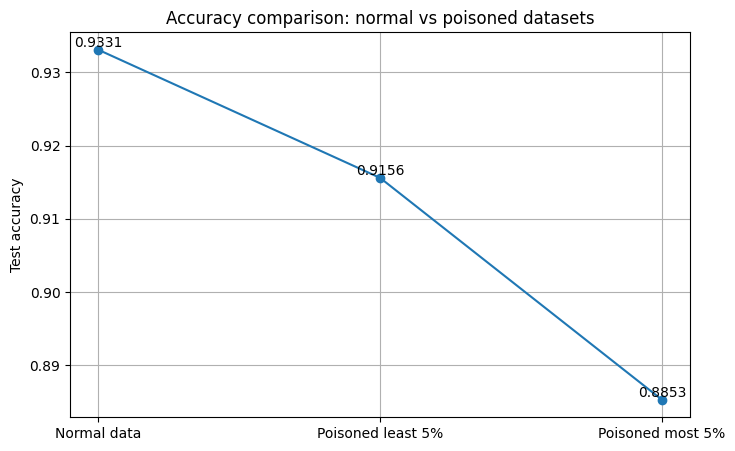

Plot saved to: plots/final_accuracy_3_points.png


In [203]:
# =========================
# 31. Final 3-point accuracy graph
# =========================
import matplotlib.pyplot as plt

baseline_acc = float(final_test_acc) #Accuracy базовой модели на нормальных данных.
least_acc = float(least_metrics["final_test_accuracy"]) #Accuracy модели, обученной на датасете, где были отравлены least influential 5%.
most_acc = float(most_metrics["final_test_accuracy"]) #Accuracy модели, обученной на датасете, где были отравлены most influential 5%.

labels = [
    "Normal data",
    "Poisoned least 5%",
    "Poisoned most 5%"
]
values = [baseline_acc, least_acc, most_acc]

plt.figure(figsize=(8, 5)) #размер окна
plt.plot(labels, values, marker="o") #построени графика с кружком в каждой точке
plt.ylabel("Test accuracy")
plt.title("Accuracy comparison: normal vs poisoned datasets")
plt.grid(True) #сетка

for x, y in zip(labels, values):
  #выравнивание, текст чуть над точкой
    plt.text(x, y, f"{y:.4f}", ha="center", va="bottom")

plot_path = "plots/final_accuracy_3_points.png" #куда сохранить
plt.savefig(plot_path, bbox_inches="tight") #сохраняем, обрезав пустые поля
plt.show()

print("Plot saved to:", plot_path)

In [202]:
# =========================
# 32. Save final comparison to JSON
# =========================
comparison = {
    "timestamp": datetime.now().isoformat(),
    "random_seed": seed,
    "normal_data_accuracy": float(baseline_acc),
    "poisoned_least_5_percent_accuracy": float(least_acc),
    "poisoned_most_5_percent_accuracy": float(most_acc)
}

comparison_path = "logs/final_accuracy_comparison.json"
with open(comparison_path, "w", encoding="utf-8") as f:
    json.dump(comparison, f, ensure_ascii=False, indent=2)

print("Final comparison saved to:", comparison_path)
print(json.dumps(comparison, ensure_ascii=False, indent=2))

Final comparison saved to: logs/final_accuracy_comparison.json
{
  "timestamp": "2026-03-19T23:41:12.304764",
  "random_seed": 42,
  "normal_data_accuracy": 0.9331,
  "poisoned_least_5_percent_accuracy": 0.9156,
  "poisoned_most_5_percent_accuracy": 0.8853
}
